In [5]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached narwhals-2.21.2-py3-none-any.whl.metadata (16 kB)
Using cached plotly-6.7.0-py3-none-any.whl (9.9 MB)
Using cached narwhals-2.21.2-py3-none-any.whl (451 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [plotly]━━━━ 1/2 [plotly]
Note: you may need to restart the kernel to use updated packages.


# 📢 Étape 7 : Data Storytelling & Communication (Squelette Étudiant)

Cette étape correspond au septième et dernier chapitre de data science. L'objectif est de synthétiser vos résultats pour des profils métiers ou décideurs et de proposer des visualisations interactives ou dynamiques pour valoriser vos conclusions.

### 1. IMPORTS ET RECONSTITUTION DU TABLEAU PRÉDICTIF

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(os.path.join('..')))
import src.train_models as tm
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

# Rechargement des données et prédictions du champion XGBoost
df_final = pd.read_csv("../data/processed/football_final_features.csv")
X_train, X_test, y_train, y_test, num_cols, cat_cols = tm.prepare_data(df_final)

preprocessor = tm.build_preprocessing_pipeline(num_cols, cat_cols)
xgb_champion = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1))
])
xgb_champion.fit(X_train, y_train)

# Création du DataFrame global de communication
df_com = X_test.copy()
df_com['Vrai_Prix'] = np.expm1(y_test)
df_com['Prix_Predit'] = np.expm1(xgb_champion.predict(X_test))

# Calcul de l'opportunité de marché (Prix Prédit / Vrai Prix)
# Si Ratio > 1.3 : Le joueur produit des stats de haut niveau mais vaut pas cher -> Une pépite !
df_com['Market_Opportunity_Ratio'] = df_com['Prix_Predit'] / (df_com['Vrai_Prix'] + 1)

print("[INFO] Données prêtes pour l'analyse décisionnelle.")

[INFO] Données prêtes pour l'analyse décisionnelle.


### 2. STRATÉGIE MONEYBALL - LE TOP 5 DES PÉPITES CACHÉES

In [2]:
# On cherche des joueurs de moins de 25 ans, sous-évalués par le marché, avec un vrai potentiel
pepites = df_com[
    (df_com['age'] <= 25) & 
    (df_com['Vrai_Prix'] >= 1000000) & # On évite les valeurs trop petites
    (df_com['Market_Opportunity_Ratio'] > 1.3)
].sort_values(by='Market_Opportunity_Ratio', ascending=False).head(5)

print("\n" + "="*50)
print("--- TOP 5 DES PÉPITES CACHÉES DÉTECTÉES PAR L'IA ---")
print("="*50)
for idx, row in pepites.iterrows():
    print(f"Poste: {row['position']} | Âge: {row['age']} ans")
    print(f"  -> Valeur Transfermarkt actuelle : {row['Vrai_Prix']:,.0f} €")
    print(f"  -> Valeur estimée selon ses performances : {row['Prix_Predit']:,.0f} €")
    print(f"  -> Indice de sous-évaluation : +{((row['Market_Opportunity_Ratio']-1)*100):.1f}% de valeur théorique\n")


--- TOP 5 DES PÉPITES CACHÉES DÉTECTÉES PAR L'IA ---
Poste: Attack | Âge: 25.0 ans
  -> Valeur Transfermarkt actuelle : 1,200,000 €
  -> Valeur estimée selon ses performances : 7,140,182 €
  -> Indice de sous-évaluation : +495.0% de valeur théorique

Poste: Midfield | Âge: 18.0 ans
  -> Valeur Transfermarkt actuelle : 2,000,000 €
  -> Valeur estimée selon ses performances : 11,616,938 €
  -> Indice de sous-évaluation : +480.8% de valeur théorique

Poste: Defender | Âge: 22.0 ans
  -> Valeur Transfermarkt actuelle : 1,200,000 €
  -> Valeur estimée selon ses performances : 6,016,216 €
  -> Indice de sous-évaluation : +401.4% de valeur théorique

Poste: Midfield | Âge: 24.0 ans
  -> Valeur Transfermarkt actuelle : 1,200,000 €
  -> Valeur estimée selon ses performances : 5,782,004 €
  -> Indice de sous-évaluation : +381.8% de valeur théorique

Poste: Attack | Âge: 24.0 ans
  -> Valeur Transfermarkt actuelle : 1,200,000 €
  -> Valeur estimée selon ses performances : 5,021,356 €
  -> Indice

### 3. VISUALISATION POUR LES DÉCIDEURS - ERREUR VS VALEUR

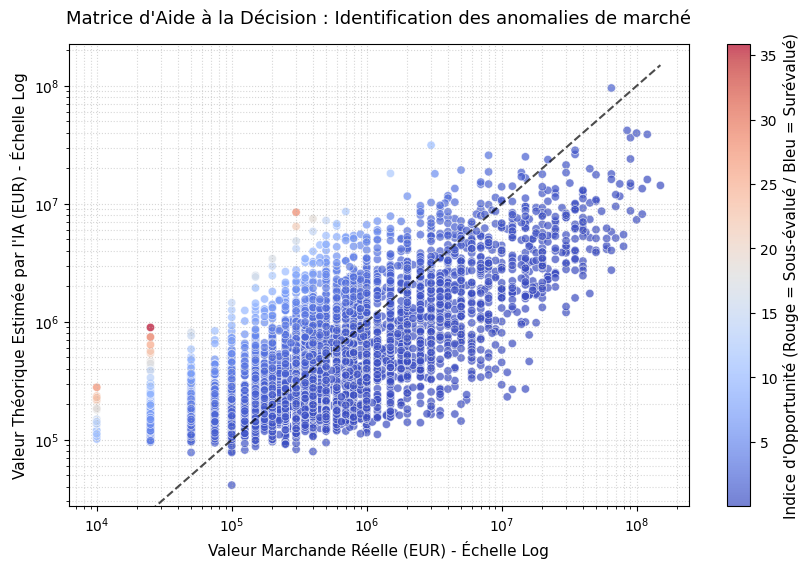

In [3]:
plt.figure(figsize=(10, 6))

# Abscisse : Vrai Prix, Ordonnée : Prix Prédit, Couleur : Ratio d'opportunité
scatter = plt.scatter(
    df_com['Vrai_Prix'], 
    df_com['Prix_Predit'], 
    c=df_com['Market_Opportunity_Ratio'], 
    cmap='coolwarm', 
    alpha=0.7, 
    edgecolors='w', 
    linewidth=0.5
)

# Ligne de référence
max_val = max(df_com['Vrai_Prix'].max(), df_com['Prix_Predit'].max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', alpha=0.7, label="Prix Juste")

plt.xscale('log')
plt.yscale('log')
cbar = plt.colorbar(scatter)
cbar.set_label("Indice d'Opportunité (Rouge = Sous-évalué / Bleu = Surévalué)", fontsize=11)

plt.title("Matrice d'Aide à la Décision : Identification des anomalies de marché", fontsize=13, pad=15)
plt.xlabel("Valeur Marchande Réelle (EUR) - Échelle Log", fontsize=11)
plt.ylabel("Valeur Théorique Estimée par l'IA (EUR) - Échelle Log", fontsize=11)
plt.grid(True, which="both", linestyle=":", alpha=0.5)

# Sauvegarde pour Quarto
os.makedirs("../report/figures/", exist_ok=True)
plt.savefig("../report/figures/market_decision_matrix.png", dpi=300)
plt.show()

### 4. VISUALISATION INTERACTIVE AVEC PLOTLY 

In [6]:

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.io as pio
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline

# 1. Configuration des chemins et chargement des données
sys.path.append(os.path.abspath(os.path.join('..')))
import src.train_models as tm

df_final = pd.read_csv("../data/processed/football_final_features.csv")
X_train, X_test, y_train, y_test, num_cols, cat_cols = tm.prepare_data(df_final)

# 2. Entraînement rapide du modèle champion XGBoost pour générer les prédictions
preprocessor = tm.build_preprocessing_pipeline(num_cols, cat_cols)
xgb_champion = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(n_estimators=150, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1))
])
xgb_champion.fit(X_train, y_train)

# 3. Création du DataFrame global de communication (df_com)
df_com = X_test.copy()
df_com['Vrai_Prix'] = np.expm1(y_test)
df_com['Prix_Predit'] = np.expm1(xgb_champion.predict(X_test))
df_com['Market_Opportunity_Ratio'] = df_com['Prix_Predit'] / (df_com['Vrai_Prix'] + 1)

# 4. Préparation des données pour Plotly (Arrondis en Millions d'Euros)
df_plotly = df_com.copy()
df_plotly['Vrai_Prix_M€'] = (df_plotly['Vrai_Prix'] / 1_000_000).round(2)
df_plotly['Prix_Predit_M€'] = (df_plotly['Prix_Predit'] / 1_000_000).round(2)
df_plotly['Indice_Opportunite'] = df_plotly['Market_Opportunity_Ratio'].round(2)

print("[INFO] Données chargées. Génération du graphique Plotly avec palette native...")

# 5. Création du graphique interactif
fig = px.scatter(
    df_plotly,
    x='Vrai_Prix_M€',
    y='Prix_Predit_M€',
    color='Indice_Opportunite',
    color_continuous_scale='RdYlBu_r', 
    log_x=True, 
    log_y=True,
    title="<b>Matrice Interactive d'Aide à la Décision (Scouting)</b>",
    labels={
        'Vrai_Prix_M€': 'Valeur Réelle Transfermarkt (Millions d\'Euros)',
        'Prix_Predit_M€': 'Valeur Estimée par l\'IA (Millions d\'Euros)',
        'Indice_Opportunite': 'Ratio d\'Opportunité'
    },
    hover_data={
        'position': True,
        'age': True,
        'Vrai_Prix_M€': ':.2f',
        'Prix_Predit_M€': ':.2f',
        'Indice_Opportunite': ':.2f'
    }
)

# 6. Ajout de la ligne diagonale de référence (Prix Juste)
max_val = max(df_plotly['Vrai_Prix_M€'].max(), df_plotly['Prix_Predit_M€'].max())
fig.add_shape(
    type="line",
    x0=0.1, y0=0.1, x1=max_val, y1=max_val,
    line=dict(color="Black", width=2, dash="dash"),
)

# 7. Amélioration du design global (Style moderne)
fig.update_layout(
    template="plotly_white",
    xaxis=dict(gridcolor='#f3f4f6'),
    yaxis=dict(gridcolor='#f3f4f6'),
    title_font=dict(size=16),
    margin=dict(l=40, r=40, t=50, b=40)
)

# 8. Sauvegarde du fichier HTML interactif pour ton rapport Quarto
os.makedirs("../report/figures/", exist_ok=True)
output_html_path = "../report/figures/market_decision_interactive.html"
pio.write_html(fig, file=output_html_path, auto_open=True)

print(f"[SUCCÈS] Graphique interactif Plotly généré et sauvegardé dans : {output_html_path}")

[INFO] Données chargées. Génération du graphique Plotly avec palette native...
[SUCCÈS] Graphique interactif Plotly généré et sauvegardé dans : ../report/figures/market_decision_interactive.html


Opening in existing browser session.
